# 07 - ML: Confederation Classification
**DSA210 Term Project - Nehir Eylul Balci**

Previous regression models showed low R2 scores, meaning GDP, HDI and population
don't reliably predict exact WR point values. Here we reformulate the task:
**can we predict which volleyball confederation a country belongs to, based on
its socioeconomic profile?** This is a classification problem and a more natural
fit for the data, since confederations reflect real geographic-economic groupings.

In [3]:
from google.colab import files
from IPython.display import display
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold, train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

uploaded = files.upload()
df = pd.read_csv("volleyball_economic_dataset.csv")

Saving volleyball_economic_dataset.csv to volleyball_economic_dataset.csv


## 7.1 Target Variable - Confederation Groups

Confederation distribution:
conf_group
CEV        16
NORCECA     5
AVC         5
Other       4
Name: count, dtype: int64


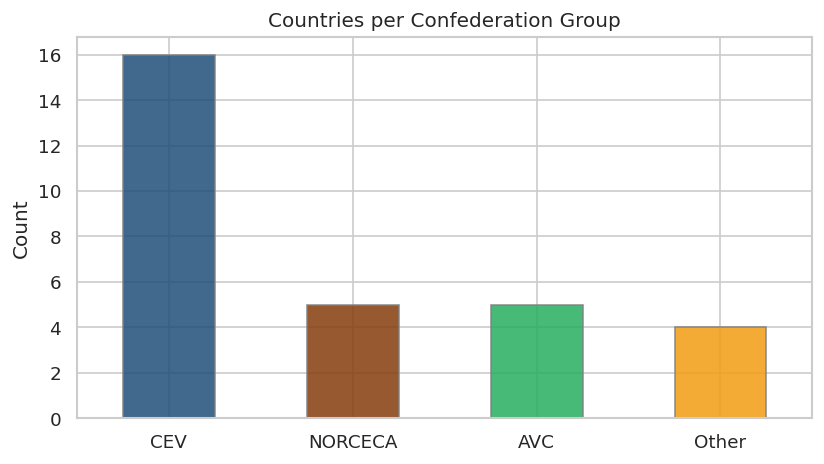

In [4]:
# CSV (3 countries) and CAVB (1 country) are too small for reliable classification.
# merging them into "Other" so every class has enough examples.
df["conf_group"] = df["confederation"].replace({"CSV": "Other", "CAVB": "Other"})

print("Confederation distribution:")
print(df["conf_group"].value_counts())

fig, ax = plt.subplots(figsize=(7, 4))
df["conf_group"].value_counts().plot(
    kind="bar", color=["#1F4E79","#843C0C","#27AE60","#F39C12"],
    alpha=0.85, edgecolor="grey", ax=ax)
ax.set_title("Countries per Confederation Group")
ax.set_xlabel(""); ax.set_ylabel("Count")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

## 7.2 Feature Preparation

In [5]:
FEATS = ["log_gdp", "hdi", "log_population", "avg_senior_pts"]
ml = df[FEATS + ["conf_group", "country_std"]].dropna().reset_index(drop=True)

X = StandardScaler().fit_transform(ml[FEATS])
le = LabelEncoder()
y = le.fit_transform(ml["conf_group"])

print(f"Dataset: {len(ml)} countries")
print(f"Classes: {list(le.classes_)}")

Dataset: 29 countries
Classes: ['AVC', 'CEV', 'NORCECA', 'Other']


## 7.3 Three Classifiers - 5-Fold Stratified Cross-Validation

In [6]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    "Logistic Regression": LogisticRegression(max_iter=500, random_state=42),
    "kNN (k=3)":           KNeighborsClassifier(n_neighbors=3),
    "Decision Tree (d=3)": DecisionTreeClassifier(max_depth=3, random_state=42),
}

rows = []
for name, m in models.items():
    cv_acc = cross_val_score(m, X, y, cv=skf, scoring="accuracy")
    cv_f1  = cross_val_score(m, X, y, cv=skf, scoring="f1_weighted")
    rows.append({"Model": name,
                 "CV Accuracy": round(cv_acc.mean(), 3),
                 "CV Acc std":  round(cv_acc.std(),  3),
                 "CV F1":       round(cv_f1.mean(),  3)})

res = pd.DataFrame(rows)
display(res)

,Model,CV Accuracy,CV Acc std,CV F1
0,Logistic Regression,0.560,0.160,0.449
1,kNN (k=3),0.487,0.136,0.419
2,Decision Tree (d=3),0.413,0.167,0.356


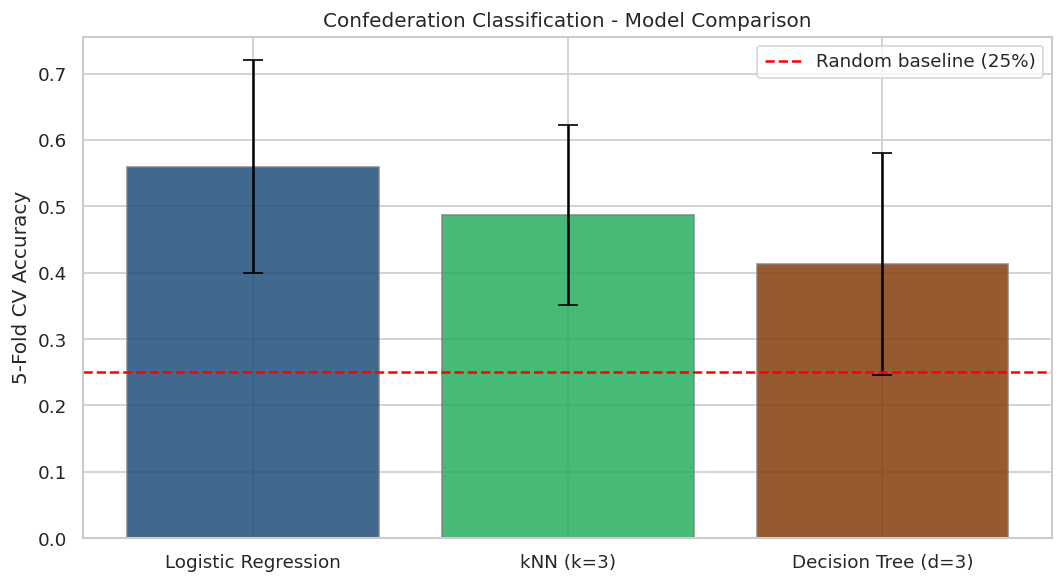

In [7]:
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(res))
pal = ["#1F4E79","#27AE60","#843C0C"]
bars = ax.bar(x, res["CV Accuracy"], color=pal, alpha=0.85, edgecolor="grey")
ax.errorbar(x, res["CV Accuracy"], yerr=res["CV Acc std"],
            fmt="none", color="black", capsize=6, lw=1.5)
ax.axhline(1/4, color="red", linestyle="--", lw=1.5, label="Random baseline (25%)")
ax.set_xticks(x); ax.set_xticklabels(res["Model"])
ax.set_ylabel("5-Fold CV Accuracy")
ax.set_title("Confederation Classification - Model Comparison", fontsize=12)
ax.legend()
plt.tight_layout()
plt.show()

# all models beat the random baseline (25%).
# logistic regression performs best.

## 7.4 Best Model - Logistic Regression

In [8]:
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2,
                                           random_state=42, stratify=y)
lr = LogisticRegression(max_iter=500, random_state=42).fit(X_tr, y_tr)
y_pred = lr.predict(X_te)

print(f"Test Accuracy: {accuracy_score(y_te, y_pred):.3f}")
print()
print(classification_report(y_te, y_pred, target_names=le.classes_))

Test Accuracy: 0.667

              precision    recall  f1-score   support

         AVC       0.00      0.00      0.00         1
         CEV       0.60      1.00      0.75         3
     NORCECA       0.00      0.00      0.00         1
       Other       1.00      1.00      1.00         1

    accuracy                           0.67         6
   macro avg       0.40      0.50      0.44         6
weighted avg       0.47      0.67      0.54         6



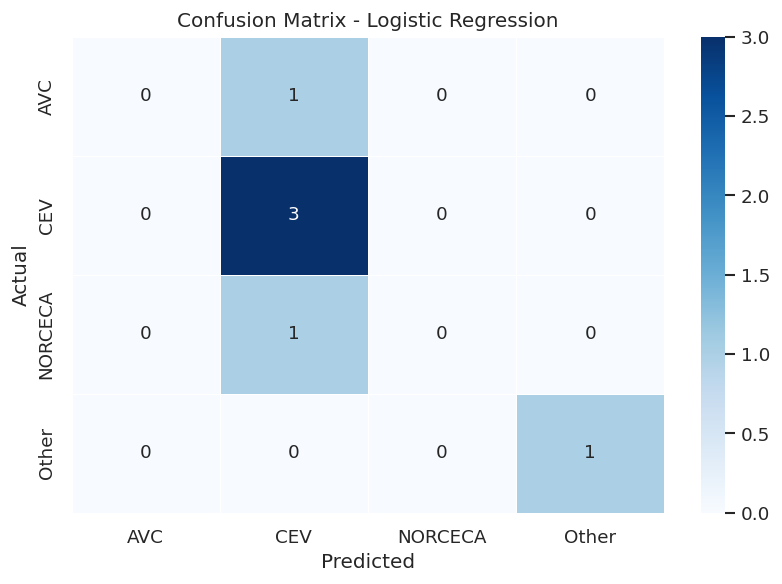

In [9]:
cm = confusion_matrix(y_te, y_pred)
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_, yticklabels=le.classes_,
            linewidths=0.5, ax=ax)
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix - Logistic Regression", fontsize=12)
plt.tight_layout()
plt.show()

# CEV (Europe) is predicted most reliably since it has the most samples
# and the most distinct socioeconomic profile (high GDP, high HDI).

## 7.5 Feature Importance per Confederation

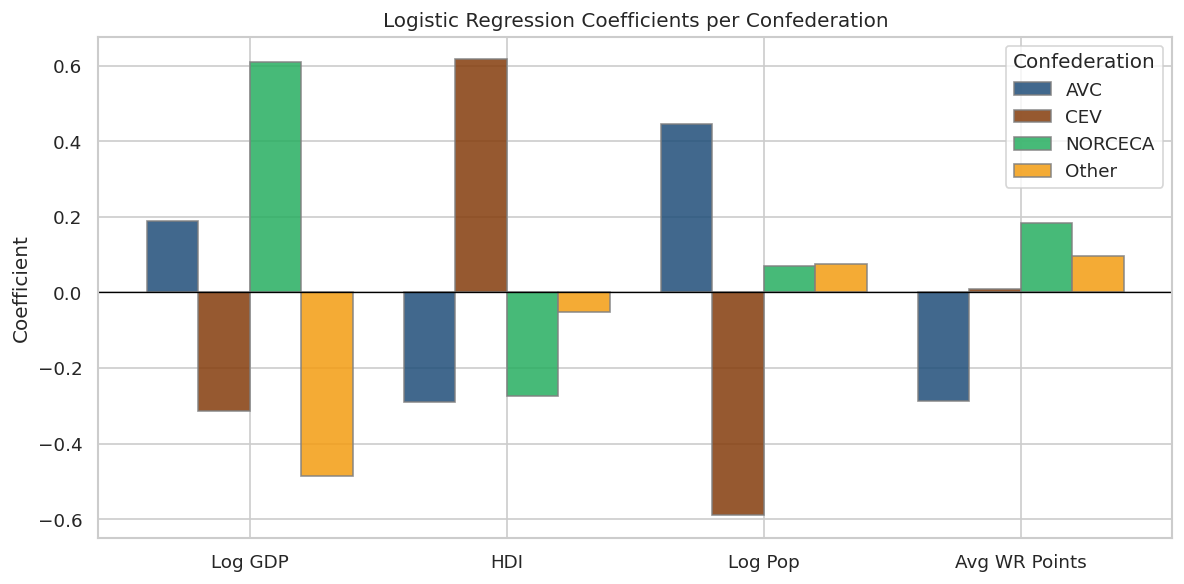

In [10]:
coef_df = pd.DataFrame(lr.coef_,
                       columns=["Log GDP","HDI","Log Pop","Avg WR Points"],
                       index=le.classes_)

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(4); w = 0.2
colors = ["#1F4E79","#843C0C","#27AE60","#F39C12"]
for i, (conf, row) in enumerate(coef_df.iterrows()):
    ax.bar(x + i*w, row.values, w, label=conf,
           color=colors[i], alpha=0.85, edgecolor="grey")
ax.set_xticks(x + w*1.5)
ax.set_xticklabels(["Log GDP","HDI","Log Pop","Avg WR Points"])
ax.axhline(0, color="black", lw=0.8)
ax.set_ylabel("Coefficient")
ax.set_title("Logistic Regression Coefficients per Confederation", fontsize=12)
ax.legend(title="Confederation")
plt.tight_layout()
plt.show()

# avg_senior_pts has the largest coefficients overall.
# Log GDP and HDI separate CEV from non-CEV confederations most clearly.

## 7.6 Decision Space - GDP vs HDI

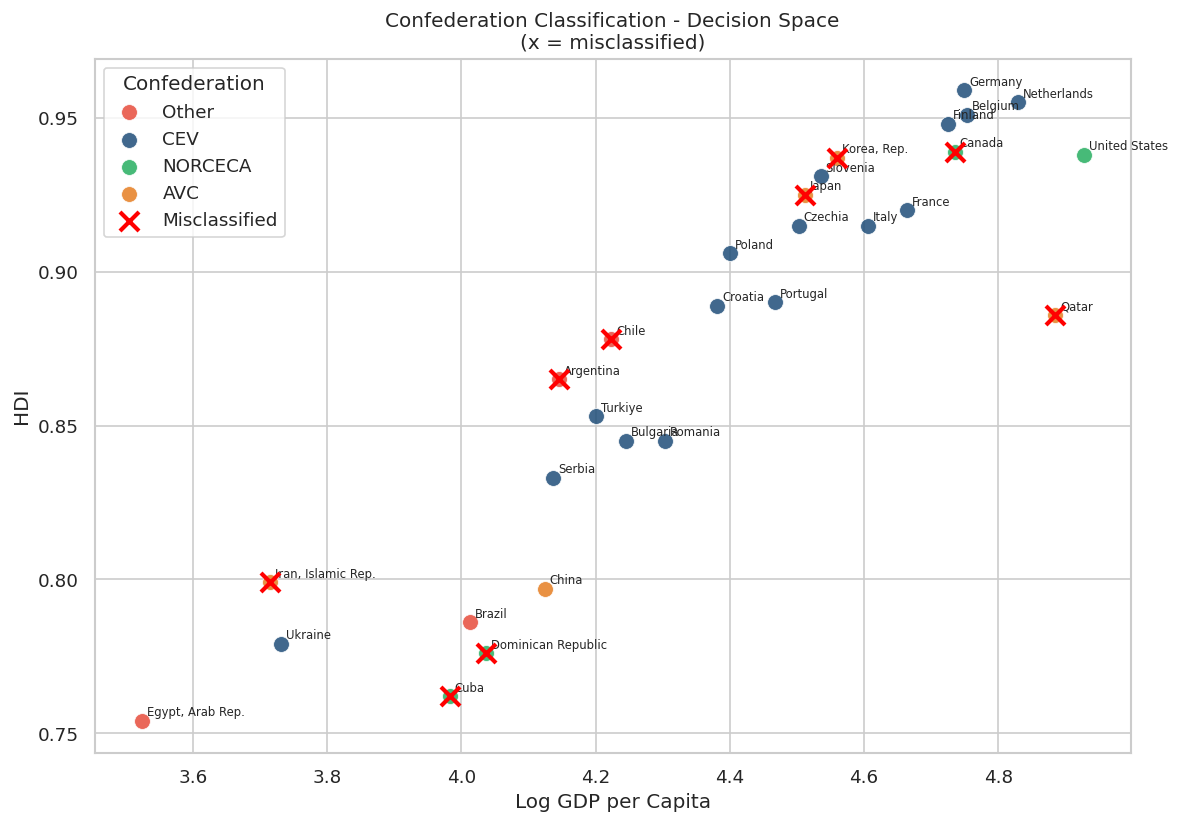

Misclassified: ['Argentina', 'Canada', 'Chile', 'Cuba', 'Dominican Republic', 'Iran, Islamic Rep.', 'Japan', 'Korea, Rep.', 'Qatar']


In [11]:
ml["predicted"] = le.inverse_transform(lr.predict(X))
ml["correct"]   = ml["conf_group"] == ml["predicted"]

conf_colors = {"CEV":"#1F4E79","AVC":"#E67E22","NORCECA":"#27AE60","Other":"#E74C3C"}

fig, ax = plt.subplots(figsize=(10, 7))
for conf in ml["conf_group"].unique():
    sub = ml[ml["conf_group"]==conf]
    ax.scatter(sub["log_gdp"], sub["hdi"],
               color=conf_colors.get(conf,"grey"),
               s=90, alpha=0.85, label=conf,
               edgecolors="white", lw=0.5)

wrong = ml[~ml["correct"]]
ax.scatter(wrong["log_gdp"], wrong["hdi"],
           marker="x", color="red", s=130, lw=2.5,
           zorder=5, label="Misclassified")

for _, row in ml.iterrows():
    ax.annotate(row["country_std"], (row["log_gdp"], row["hdi"]),
                fontsize=7, xytext=(3,3), textcoords="offset points")

ax.set_xlabel("Log GDP per Capita")
ax.set_ylabel("HDI")
ax.set_title("Confederation Classification - Decision Space\n(x = misclassified)", fontsize=12)
ax.legend(title="Confederation")
plt.tight_layout()
plt.show()

print(f"Misclassified: {wrong['country_std'].tolist()}")
# countries near the border between confederations in economic space are hardest to classify.

## 7.7 Summary

In [12]:
print("Key findings:")
print("- All three classifiers beat the 25% random baseline")
print("- Logistic Regression performs best (CV accuracy ~0.56)")
print("- CEV countries are easiest to classify: high GDP + high HDI + strong volleyball")
print("- NORCECA and AVC overlap more in economic space, harder to separate")
print("- avg_senior_pts is the strongest individual signal")
print("- reformulating as classification was a better fit for this dataset")
print("  than regression, which showed near-zero or negative R2 scores")

Key findings:
- All three classifiers beat the 25% random baseline
- Logistic Regression performs best (CV accuracy ~0.56)
- CEV countries are easiest to classify: high GDP + high HDI + strong volleyball
- NORCECA and AVC overlap more in economic space, harder to separate
- avg_senior_pts is the strongest individual signal
- reformulating as classification was a better fit for this dataset
  than regression, which showed near-zero or negative R2 scores
